# Boilerplate (imports)

In [40]:
import os
import sys 
import cobra
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import torch
import scipy
import scipy.stats as stats
import sys
import os.path
import gurobipy # make sure some solver backend is available for iMAT/FBA/MoMA
from projection_methods import MoMAWrapper, FBApro, FBAWrapper, IMATWrapper
import util

In [41]:
# Set up gurobi or other optimizer license file if needed
# os.environ['GRB_LICENSE_FILE'] = "/path/to/your/gurobi.lic"
os.environ['GRB_LICENSE_FILE'] = "../argo_comp1_grb_key/gurobi.lic"


# Test with iid noise to steady-state data

## Generate data

In [42]:
%%time

reaction_size_cutoff = 20000 # > 10600 for all models in model_organism_* variables
n_samples_per_graph = 10
base_noise_power = 1
base_frac_known_reactions = 0.1
device = torch.device("cpu")

models = list()
As = list()
ss_bases = list()
ss_fluxes = list()
perturbed_fluxes = list()
names = list()
masks = list()

data_dir = 'synthetic_data_experiment_files/data' # make sure this has the models specified below, in sbml format. 
caching_dir = 'synthetic_data_experiment_files/caching'
export_path = 'synthetic_data_experiment_files/outputs'
    
model_organism_model_names = ['e_coli_core', 'iML1515', 'iND750', 'iMM1415', 'RECON1', 'Recon3D']
model_organism_organisms = ['e_coli_core', 'e_coli_K_12', 'yeast', 'mouse', 'human_1', 'human_3d']
model_name_to_organism = {k: v for k, v in zip(model_organism_model_names, model_organism_organisms)}
# ordered_organisms = []

for i, model_filename in enumerate(os.listdir(data_dir)):
    name = model_filename.split('.')[0]
    if name not in model_organism_model_names:
        continue
    model = cobra.io.read_sbml_model(os.path.join(data_dir, model_filename))
    if len(model.reactions) > reaction_size_cutoff:
        continue    
    models.append(model)
    if os.path.exists(os.path.join(caching_dir, name + "_cached_A.npy")):
        print(i, name, "(cached)")
        A = np.load(os.path.join(caching_dir, name + "_cached_A.npy"))
        basis = np.load(os.path.join(caching_dir, name + "_cached_basis.npy")) 
    else:
        print(i, name)
        A = cobra.util.create_stoichiometric_matrix(model)
        basis = scipy.linalg.null_space(A) # a reactions X kernel-dimension array
        np.save(os.path.join(caching_dir, name + "_cached_A"), A)
        np.save(os.path.join(caching_dir, name + "_cached_basis"), basis) 
        
    print("Model shape: {}".format(A.shape))
    As.append(A)
    names.append(model_filename.split(".")[0])

    # A = A.astype(float)

    print("ss basis shape:", basis.shape)
    
    ss_bases.append(basis)
    
    coefficients = np.random.random(size=(basis.shape[1], n_samples_per_graph))
    steady_states = (basis @ coefficients).transpose() # a samples X reactions array.
    ss_fluxes.append(steady_states)
    
    known_indices = np.array(sorted(np.random.choice(np.array(list(range(A.shape[1]))), size=math.ceil(base_frac_known_reactions * A.shape[1]), replace=False)))
    mask = np.zeros(A.shape[1],dtype=bool)
    mask[known_indices] = True    

    noised_steady_states = [ss * (1 + base_noise_power * 2 * (np.random.random(size=ss.shape) - 0.5))
                            for ss in steady_states]
    blanked_noised_steady_states = [np.where(mask, ss, 0) for ss in noised_steady_states]

    blanked_noised_steady_states = np.array(blanked_noised_steady_states)
    perturbed_fluxes.append(blanked_noised_steady_states)
    masks.append(mask)
    
    
ys = [torch.tensor(y.astype(np.float64)) for y in ss_fluxes]
Xs = [torch.tensor(X.astype(np.float64)) for X in perturbed_fluxes]

n_graphs = len(As)

0 iND750 (cached)
Model shape: (1059, 1266)
ss basis shape: (1266, 284)
1 e_coli_core (cached)
Model shape: (72, 95)
ss basis shape: (95, 28)
2 RECON1 (cached)
Model shape: (2766, 3741)
ss basis shape: (3741, 1067)


No objective coefficients in model. Unclear what should be optimized


3 iMM1415 (cached)
Model shape: (2775, 3726)
ss basis shape: (3726, 1041)
4 iML1515 (cached)
Model shape: (1877, 2712)
ss basis shape: (2712, 867)
CPU times: user 38.9 s, sys: 1.63 s, total: 40.5 s
Wall time: 24.1 s


In [43]:
for model in models:
    # Open up all exchanges and blocked reactions with high bounds
    for r in model.reactions:
        bounds = [r.bounds[0], r.bounds[1]]
        if bounds[0] < 0:
            bounds[0] = -1000
        if bounds[1] > 0:
            bounds[1] = 1000
        # if bounds[1] == 1000:
        #     bounds[1] = 10
        # if bounds[0] == -1000:
        #     bounds[0] = -10
        if bounds == (0, 0):
            bounds = -1000, 1000
        # if "ex" in r.id.lower(): 
        #     bounds = (-10, 10)
        r.bounds = bounds

In [44]:
# Generate approximate bounds to be used for FBA and iterative projection versions
ls = []
us = []
epsilon = 1e-5
for model_index, model, X, Y, mask in zip(list(range(len(models))), models, Xs, ys, masks):
    print(model_index)
    # print(model_index, len(model.reactions), len(models), X.shape, Y.shape, mask.shape)
    l = np.zeros(shape=(X.shape[0], X.shape[1]))
    u = np.zeros(shape=(X.shape[0], X.shape[1]))
    for j, r in enumerate(model.reactions):
        l[:, j] = r.bounds[0]
        u[:, j] = r.bounds[1]
    for i, sample in enumerate(Y):
        # Change bounds to the gap that was possible during the noise generation if measured
        sign = torch.sign(sample)
        l[i, :] = np.where(mask, (1 - base_noise_power * sign ) * sample, l[i, :])
        u[i, :] = np.where(mask, (1 + base_noise_power * sign ) * sample, u[i, :])
        
    l = torch.tensor(l, dtype=torch.float, device=device)
    u = torch.tensor(u, dtype=torch.float, device=device)
    ls.append(l)
    us.append(u)

0
1
2
3
4


## Apply projection and FBA on zeroed data

In [45]:
%%time

    
methods = [
          FBApro, 
          FBAWrapper,
          IMATWrapper,
          MoMAWrapper
            ]

method_names = [] # right now only use the appropriate version of FBApro
containers = [[] for method in methods]


for i, model, A, X, mask, l, u, basis in zip(range(len(models)), models, As, Xs, masks, ls, us, ss_bases):
    print(i)

    obj_coefs = {rxn.id: rxn.objective_coefficient for rxn in model.reactions if rxn.objective_coefficient != 0}
    print(obj_coefs)
    print([r.id for r in model.reactions if 'biomass' in r.id.lower()])
    if len(obj_coefs) == 0:
        growth_related_reactions = [r.id for r in model.reactions if 'biomass' in r.id.lower()]
        assert len(growth_related_reactions) == 1
        obj_coefs = {growth_related_reactions[0]: 1}
    assert len(obj_coefs) == 1 and all([v == 1 for k, v in obj_coefs.items()])
    objective_reaction_ids = obj_coefs.popitem()[0]

    with model:
        # obj = linear_reaction_coefficients(model)
        # assert len(obj) == 1
        # objective_id = obj.popitem()[0].id
        unknown_indices = [q for q in range(len(mask)) if ~(mask[q])]
        measured_indices = [q for q in range(len(mask)) if mask[q]]
        for method, container in zip(methods, containers): 
            proj = method(stoichiometric_matrix=A, model=model, unknown_indices=unknown_indices,                           steady_state_basis_matrix=basis, 
                          l_bounds=l, u_bounds=u, device=device, objective_id = objective_reaction_ids,
                          dtype=torch.float)
            method_names.append(str(method))
            y_pred = proj.forward(X.to(dtype=torch.float, device=device), l_bounds=l, u_bounds=u)
            container.append(y_pred)
            del proj

0
{'BIOMASS_SC4_bal': 1.0}
['BIOMASS_SC4_bal']
output - abs min: 5.45e-19, abs max: 1.90e+00, abs mean: 1.01e-01
S * output - abs min: 0.00e+00, abs max: 3.10e-06, abs mean: 3.73e-08
Suppressing further warnings.
Sample 0
Sample 1
Sample 2
Sample 3
Sample 4
Sample 5
Sample 6
Sample 7
Sample 8
Sample 9
1
{'BIOMASS_Ecoli_core_w_GAM': 1.0}
['BIOMASS_Ecoli_core_w_GAM']
output - abs min: 2.14e-05, abs max: 1.61e+00, abs mean: 1.51e-01
S * output - abs min: 0.00e+00, abs max: 1.43e-06, abs mean: 4.41e-08
Suppressing further warnings.


/Genomics/argo/users/abronner/.conda/envs/pytorch_cuda12.1/lib/python3.12/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Sample 0
Sample 1
Sample 2
Sample 3
Sample 4
Sample 5
Sample 6
Sample 7
Sample 8
Sample 9
2
{'S6T14g': 1.0}
[]
output - abs min: 1.39e-19, abs max: 3.01e+00, abs mean: 1.08e-01
S * output - abs min: 0.00e+00, abs max: 7.78e-06, abs mean: 6.14e-08
Suppressing further warnings.
Sample 0
Sample 1
Sample 2
Sample 3
Sample 4
Sample 5
Sample 6
Sample 7
Sample 8
Sample 9
3
{}
['BIOMASS_mm_1_no_glygln']
output - abs min: 1.84e-19, abs max: 2.39e+00, abs mean: 9.66e-02
S * output - abs min: 0.00e+00, abs max: 4.99e-06, abs mean: 4.75e-08
Suppressing further warnings.
Sample 0
Sample 1
Sample 2
Sample 3
Sample 4
Sample 5
Sample 6
Sample 7
Sample 8
Sample 9
4
{'BIOMASS_Ec_iML1515_core_75p37M': 1.0}
['BIOMASS_Ec_iML1515_core_75p37M', 'BIOMASS_Ec_iML1515_WT_75p37M']
output - abs min: 2.24e-18, abs max: 3.11e+01, abs mean: 5.55e-01
S * output - abs min: 0.00e+00, abs max: 9.49e-04, abs mean: 9.42e-07
Suppressing further warnings.
Sample 0
Sample 1
Sample 2
Sample 3
Sample 4
Sample 5
Sample 6
Sample 

In [46]:
entries = []

for i, y in enumerate(ys):
    print(i)
    method_names = [m.__repr__(None) for m in methods]
    for method_name, container in zip(method_names, containers):
        for metric in ['spearmanr', 'l2']:
            if metric == 'l2':
                continue
            corr_func = stats.spearmanr if metric == 'spearmanr' else lambda a, b, nan_policy='omit': (-scipy.linalg.norm((a - b).values, axis=0), 0)
            for masking in ['all', 'known', 'unknown']:
                if masking == 'all':
                    continue
                    # mask = torch.ones_like(y[0], dtype=torch.bool)
                elif masking == 'known':
                    mask = torch.tensor(masks[i], dtype=torch.bool)
                else:
                    mask = ~torch.tensor(masks[i], dtype=torch.bool)
                for axis in ['per sample', 'per reaction']:
                    data = y[:, mask]
                    preds = container[i][:, mask]
                    if axis == 'per sample':
                        # continue
                        data = data.transpose(0, 1)
                        preds = preds.transpose(0, 1)
                        # assert sizes match and make them into dfs
                    assert data.shape == preds.shape
                    data = pd.DataFrame(data)
                    preds = pd.DataFrame(preds.cpu())
                    corrs, _, full_corr, _ = util.run_correlation_tests(data, preds, corr_func=corr_func, parallel=False)
                    # function is run per columns, transpose if doing per sample.
                    if axis == 'per sample':
                        assert len(corrs) == y[:, mask].shape[0]
                    else:
                        assert len(corrs) == y[:, mask].shape[1]
                    for val in corrs.values():
                        if np.isnan(val):
                            val = 0
                        entries.append({'model': model_name_to_organism[models[i].id], 'method': method_name, 'metric': metric, 'axis': axis, 'masking': masking, 'value': val})

0


/Genomics/singhlab/abronner/fbapro/util.py:97: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  full_corr, full_pvalue = corr_func(df1_relevant_flattened.astype('float')[~nan_indices],
/Genomics/singhlab/abronner/fbapro/util.py:97: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  full_corr, full_pvalue = corr_func(df1_relevant_flattened.astype('float')[~nan_indices],


1
2


/Genomics/singhlab/abronner/fbapro/util.py:97: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  full_corr, full_pvalue = corr_func(df1_relevant_flattened.astype('float')[~nan_indices],
/Genomics/singhlab/abronner/fbapro/util.py:97: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  full_corr, full_pvalue = corr_func(df1_relevant_flattened.astype('float')[~nan_indices],


3


/Genomics/singhlab/abronner/fbapro/util.py:97: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  full_corr, full_pvalue = corr_func(df1_relevant_flattened.astype('float')[~nan_indices],
/Genomics/singhlab/abronner/fbapro/util.py:97: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  full_corr, full_pvalue = corr_func(df1_relevant_flattened.astype('float')[~nan_indices],
/Genomics/singhlab/abronner/fbapro/util.py:97: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  full_corr, full_pvalue = corr_func(df1_relevant_flattened.astype('float')[~nan_indices],
/Genomics/singhlab/abronner/fbapro/util.py:97: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  full_corr, full_pvalue = corr_func(df1_relevant_flattened.astype('float')[~nan_indices],


4


/Genomics/singhlab/abronner/fbapro/util.py:97: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  full_corr, full_pvalue = corr_func(df1_relevant_flattened.astype('float')[~nan_indices],
/Genomics/singhlab/abronner/fbapro/util.py:97: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  full_corr, full_pvalue = corr_func(df1_relevant_flattened.astype('float')[~nan_indices],


In [47]:
# convert entries to a datafram
results = pd.DataFrame.from_records(entries)
results

,model,method,metric,axis,masking,value
0,yeast,FBApro(uninitialized),spearmanr,per sample,known,0.956107
1,yeast,FBApro(uninitialized),spearmanr,per sample,known,0.964305
2,yeast,FBApro(uninitialized),spearmanr,per sample,known,0.960337
3,yeast,FBApro(uninitialized),spearmanr,per sample,known,0.976583
4,yeast,FBApro(uninitialized),spearmanr,per sample,known,0.959276
...,...,...,...,...,...,...
46555,e_coli_K_12,MoMA,spearmanr,per reaction,unknown,0.000000
46556,e_coli_K_12,MoMA,spearmanr,per reaction,unknown,0.000000
46557,e_coli_K_12,MoMA,spearmanr,per reaction,unknown,0.000000
46558,e_coli_K_12,MoMA,spearmanr,per reaction,unknown,0.000000


/tmp/ipykernel_80484/3665275416.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['method'] = filtered['method'].str.replace("LowMid", "Partial").str.replace("HighMid", "Fixed")
/tmp/ipykernel_80484/3665275416.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['method'] = pd.Categorical(filtered['method'],


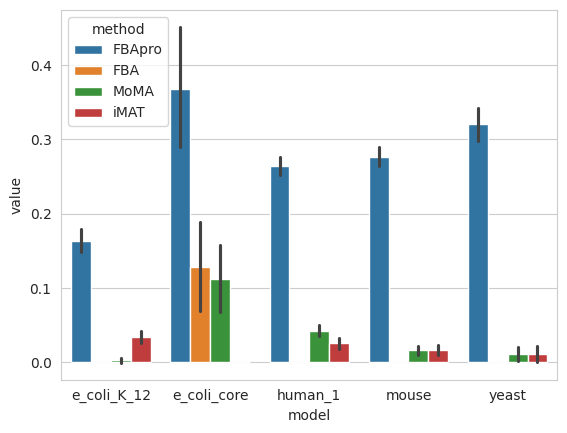

In [48]:
results['method'] = results['method'].str.replace("FBApro(uninitialized)", "FBApro")

sns.set_style("whitegrid")
filtered = results.loc[(results['metric'] == 'spearmanr') &  (results['axis'] == 'per reaction') & (results['masking'] == 'unknown')]
filtered['method'] = filtered['method'].str.replace("LowMid", "Partial").str.replace("HighMid", "Fixed")
filtered['method'] = pd.Categorical(filtered['method'], 
                                ["FBApro", 
                                 "FBA",
                                 "MoMA",
                                 "iMAT",
                                ])
sns.barplot(data=filtered.sort_values(by=['method', 'model']), hue="method", x='model', y="value")
filename =  "blanked_rxn_unknown.png"
plt.gcf().savefig(os.path.join(export_path, filename))

/tmp/ipykernel_80484/4230601673.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['method'] = filtered['method'].str.replace("LowMid", "Partial").str.replace("HighMid", "Fixed").str.replace("Reference Values", "Mid-bound Benchmark")
/tmp/ipykernel_80484/4230601673.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['method'] = pd.Categorical(filtered['method'],


<Figure size 640x480 with 0 Axes>

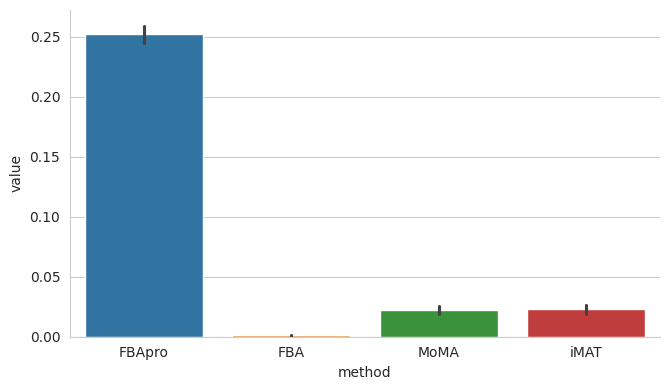

In [49]:
results['method'] = results['method'].str.replace("FBAproFixed", "FBApro")

sns.set_style('whitegrid')
filtered = results.loc[(results['metric'] == 'spearmanr') &  (results['axis'] == 'per reaction') & (results['masking'] == 'unknown')]

filtered['method'] = filtered['method'].str.replace("LowMid", "Partial").str.replace("HighMid", "Fixed").str.replace("Reference Values", "Mid-bound Benchmark")
filtered['method'] = pd.Categorical(filtered['method'], 
                                ["FBApro", 
                                 "FBA",
                                 "MoMA",
                                 "iMAT",
                                ])

plt.tight_layout()
sns.catplot(data=filtered.sort_values(by=['method']), x="method", y="value", hue='method',
                          height=4,
               aspect=1.7,
               kind='bar')

filename =  "exact_rxn_unknown.png"
plt.gcf().savefig(os.path.join(export_path, filename))

/tmp/ipykernel_80484/4248952692.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['method'] = filtered['method'].str.replace("LowMid", "Partial").str.replace("HighMid", "Fixed")
/tmp/ipykernel_80484/4248952692.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['method'] = pd.Categorical(filtered['method'],


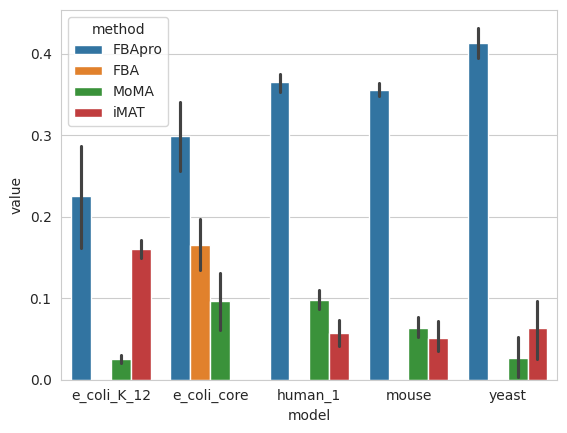

In [50]:
filtered = results.loc[(results['metric'] == 'spearmanr') &  (results['axis'] == 'per sample') & (results['masking'] == 'unknown')]
filtered['method'] = filtered['method'].str.replace("LowMid", "Partial").str.replace("HighMid", "Fixed")
filtered['method'] = pd.Categorical(filtered['method'], 
                                ["FBApro", 
                                 "FBA",
                                 "MoMA",
                                 "iMAT",
                                ])
sns.barplot(data=filtered.sort_values(by=['method', 'model']), hue="method", x='model', y="value")
filename =  "blanked_sample_unknown.png"
plt.gcf().savefig(os.path.join(export_path, filename))

# Check dependences of performance on fraction of unknown reactions

In [51]:
methods = [
          FbaProjection, 
          FbaProjectionLowMidConfidence,
          FbaProjectionHighMidConfidence,
          FBAWrapper,
          IMATWrapper,
          MoMAWrapper
            ]
method_names = [m.__repr__(None) for m in methods]


NameError: name 'FbaProjection' is not defined

In [ ]:
%%time
known_reactions_steps = list(np.linspace(start=0.05, stop=1, num=20, endpoint=False))

known_varying_entries = list()
for i, known_frac in enumerate(known_reactions_steps):
    print("known frac: {}".format(known_reactions_steps[i]))
    ss_fluxes = list()
    perturbed_fluxes = list()
    names = list()
    masks = list()

    coefficients = [np.random.random(size=(basis.shape[1], n_samples_per_graph)) for basis in ss_bases]
    steady_states = [(basis @ coef).transpose() for basis, coef in zip(ss_bases, coefficients)]     
    noised_steady_states = [ss * (1 + base_noise_power * 2 * (np.random.random(size=ss.shape) - 0.5)) 
                            for ss in steady_states]
    known_indices_list = [sorted(np.random.choice(np.array(list(range(nss.shape[1]))), size=math.ceil(known_frac * nss.shape[1]), 
                                      replace=False))
                         for nss in steady_states]
    masks = list()
    blanked_noised_steady_states = list()
    for nss, idxs in zip(noised_steady_states, known_indices_list):
        mask = np.zeros(nss.shape[1],dtype=bool)
        mask[idxs] = True
        # print("mask sum:", sum(mask))
        masks.append(mask)
        blanked = list()
        # print("ss shape:", ss.shape)
        blanked_noised_steady_states.append([np.where(mask, s, 0) for s in nss])
    
    ys = [torch.tensor(y.astype(np.float64), device=device) for y in steady_states]
    Xs = [torch.tensor(np.array(X).astype(np.float64), device=device) for X in blanked_noised_steady_states]
        
    # Generate approximate bounds to be used for FBA and iterative projection versions
    ls = []
    us = []
    for model_index, model, X, Y, mask in zip(list(range(len(models))), models, Xs, ys, masks):
        l = torch.zeros((X.shape[0], X.shape[1]), dtype=torch.float, device=device)
        u = torch.zeros((X.shape[0], X.shape[1]), dtype=torch.float, device=device)
        for j, r in enumerate(model.reactions):
            l[:, j] = r.bounds[0]
            u[:, j] = r.bounds[1]
        for i, sample in enumerate(Y):
            # Change bounds to the gap that was possible during the noise generation if known, and wide open otherwise
            sign = torch.sign(sample)
            mask = torch.tensor(mask, dtype=torch.bool, device=device)
            l[i, :] = torch.where(mask, (1 - base_noise_power * sign) * sample - epsilon, l[i, :])
            u[i, :] = torch.where(mask, (1 + base_noise_power * sign) * sample + epsilon, u[i, :])  
    
        ls.append(l)
        us.append(u)
        
    containers = [[] for method in methods]
    for model, A, basis, X, y, mask, l, u in zip(models, As, ss_bases, Xs, ys, masks, ls, us):
        obj_coefs = {rxn.id: rxn.objective_coefficient for rxn in model.reactions if rxn.objective_coefficient != 0}
        print(obj_coefs)
        print([r.id for r in model.reactions if 'biomass' in r.id.lower()])
        if len(obj_coefs) == 0:
            growth_related_reactions = [r.id for r in model.reactions if 'biomass' in r.id.lower()]
            assert len(growth_related_reactions) == 1
            obj_coefs = {growth_related_reactions[0]: 1}
        assert len(obj_coefs) == 1 and all([v == 1 for k, v in obj_coefs.items()])
        objective_reaction_ids = obj_coefs.popitem()[0]

        with model:
            unknown_indices = [q for q in range(len(mask)) if ~(mask[q])]
            measured_indices = [q for q in range(len(mask)) if mask[q]]
            for method, container in zip(methods, containers): 
                # print("A shape, X shape:", A.shape, X.shape)
                proj = method(model=model, stoichiometric_matrix=A,
                              unknown_indices=unknown_indices, measured_indices=measured_indices, steady_state_basis_matrix=basis, 
                              l_bounds=l, u_bounds=u, device=device, objective_id=objective_reaction_ids,
                              acond=1e-2, rcond=1e-2, dtype=torch.float)
                y_pred = proj.forward(X.to(dtype=torch.float, device=device), l_bounds=l, u_bounds=u)
                container.append(y_pred)
                del proj
    for i, y in enumerate(ys):
        print(i)
        for method_name, container in zip(method_names, containers):
            for metric in ['spearmanr', 'l2']:
                if metric == 'l2':
                    continue
                corr_func = stats.spearmanr if metric == 'spearmanr' else lambda a, b, nan_policy='omit': (-scipy.linalg.norm((a - b).values, axis=0), 0)
                for masking in ['all', 'known', 'unknown']:
                    if masking == 'all':
                        continue
                        mask = torch.ones_like(y[0], dtype=torch.bool, device=device)
                    elif masking == 'known':
                        mask = masks[i]
                    else:
                        mask = ~masks[i]
                    for axis in ['per sample', 'per reaction']:
                        # print("mask shape and sum:", mask.shape, sum(mask))
                        # data = y[:, mask]
                        preds = container[i][:, mask].cpu().numpy()
                        data = y[:, mask].cpu().numpy()
                        if axis == 'per sample':
                            # continue
                            data = data.transpose()
                            preds = preds.transpose()
                            # assert sizes match and make them into dfs
                        assert data.shape == preds.shape
                        data = pd.DataFrame(data)
                        preds = pd.DataFrame(preds)
                        
                        # print(data.shape, preds.shape, data.columns, preds.columns)
                        
                        corrs, _, full_corr, _ = util.run_correlation_tests(data, preds, corr_func=corr_func, parallel=False)
                        # function is run per columns, transpose if doing per sample.
                        # print(len(corrs), y[:, mask].shape, data.shape, preds.shape)
                        if axis == 'per sample':
                            assert len(corrs) == y[:, mask].shape[0]
                        else:
                            assert len(corrs) == y[:, mask].shape[1]
                        for val in corrs.values():
                            known_varying_entries.append({'known_frac': known_frac, 'model': model_name_to_organism[models[i].id], 'method': method_name, 'metric': metric, 'axis': axis, 'masking': masking, 'value': val})
        
    print("Finished iteration for known fraction {}".format(known_frac))
    
known_varying_results = pd.DataFrame.from_records(known_varying_entries)

In [ ]:
known_varying_results.to_csv(os.path.join(export_path, "figure_recreation_data", "noisy_missing_data_frac"))

In [ ]:
filtered = known_varying_results.loc[(known_varying_results['metric'] == 'spearmanr') &  (known_varying_results['axis'] == 'per reaction') & (known_varying_results['masking'] == 'unknown')]
filtered = filtered.loc[filtered['known_frac'] <= 0.5]
# sns.lineplot(data=filtered, hue="method", x='known_frac', y="value", style='model')
sns.set(rc={'figure.figsize':(10, 6)})

filtered['method'] = filtered['method'].str.replace("LowMid", "Partial").str.replace("HighMid", "Fixed")
filtered['method'] = pd.Categorical(filtered['method'], 
                                ["FBApro", 
                                 "FBAproPartial", 
                                 "FBAproFixed",
                                 "FBA",
                                 "MoMA",
                                 "iMAT",
                                ])
plt.xlabel("Fraction of known reactions")
plt.ylabel("Per Reaction Spearman Correlation")

sns.lineplot(data=filtered.sort_values(by=["method", "model"]), hue="method", x='known_frac', y="value", marker="o")
filename =  "blanked_knownfrac_varying_rxn_unknown.png"
plt.gcf().savefig(os.path.join(export_path, filename))

In [ ]:
filtered = known_varying_results.loc[(known_varying_results['metric'] == 'spearmanr') &  (known_varying_results['axis'] == 'per reaction') & (known_varying_results['masking'] == 'known')]
# sns.lineplot(data=filtered, hue="method", x='known_frac', y="value", style='model')
sns.lineplot(data=filtered.sort_values(by=["method", "model"]), hue="method", x='known_frac', y="value", marker="o")

In [ ]:
filtered = known_varying_results.loc[(known_varying_results['metric'] == 'spearmanr') &  (known_varying_results['axis'] == 'per sample') & (known_varying_results['masking'] == 'unknown')]
# sns.lineplot(data=filtered, hue="method", x='known_frac', y="value", style='model')
sns.set(rc={'figure.figsize':(10, 6)})

filtered['method'] = filtered['method'].str.replace("LowMid", "Partial").str.replace("HighMid", "Fixed")

filtered['method'] = pd.Categorical(filtered['method'], 
                                ["FBApro", 
                                 "FBAproPartial", 
                                 "FBAproFixed",
                                 "FBA",
                                 "MoMA",
                                 "iMAT",
                                ])
plt.xlabel("Fraction of known reactions")
plt.ylabel("Per Sample Spearman Correlation")



sns.lineplot(data=filtered.sort_values(by=["method", "model"]), hue="method", x='known_frac', y="value", marker="o")
filename =  "blanked_knownfrac_varying_sample_unknown.png"
plt.gcf().savefig(os.path.join(export_path, filename))

In [ ]:
filtered = known_varying_results.loc[(known_varying_results['metric'] == 'spearmanr') &  (known_varying_results['axis'] == 'per sample') & (known_varying_results['masking'] == 'known')]
# sns.lineplot(data=filtered, hue="method", x='known_frac', y="value", style='model')
sns.lineplot(data=filtered.sort_values(by=["method", "model"]), hue="method", x='known_frac', y="value", marker="o")

# Check dependences of performance on noise level

In [ ]:
methods = [
          FbaProjection, 
          FbaProjectionLowMidConfidence,
          FbaProjectionHighMidConfidence,
          FBAWrapper,
          IMATWrapper,
          MoMAWrapper
            ]
method_names = [m.__repr__(None) for m in methods]


In [ ]:
%%time
noise_power_steps = list(np.linspace(start=0.01, stop=4, num=20, endpoint=True))

noise_varying_entries = list()
for i, noise_power in enumerate(noise_power_steps):
    print("noise power: {}".format(noise_power))
    ss_fluxes = list()
    perturbed_fluxes = list()
    names = list()
    masks = list()

    coefficients = [np.random.random(size=(basis.shape[1], n_samples_per_graph)) for basis in ss_bases]
    steady_states = [(basis @ coef).transpose() for basis, coef in zip(ss_bases, coefficients)]     
    noised_steady_states = [ss * (1 + noise_power * 2 * (np.random.random(size=ss.shape) - 0.5)) 
                            for ss in steady_states]
    known_indices_list = [sorted(np.random.choice(np.array(list(range(nss.shape[1]))), size=math.ceil(base_frac_known_reactions * nss.shape[1]), 
                                      replace=False))
                         for nss in steady_states]
    masks = list()
    blanked_noised_steady_states = list()
    for nss, idxs in zip(noised_steady_states, known_indices_list):
        mask = np.zeros(nss.shape[1],dtype=bool)
        mask[idxs] = True
        # print("mask sum:", sum(mask))
        masks.append(mask)
        blanked = list()
        # print("ss shape:", ss.shape)
        blanked_noised_steady_states.append([np.where(mask, s, 0) for s in nss])
    
    ys = [torch.tensor(y.astype(np.float64), device=device) for y in steady_states]
    Xs = [torch.tensor(np.array(X).astype(np.float64), device=device) for X in blanked_noised_steady_states]
        
    # Generate approximate bounds to be used for FBA and iterative projection versions
    ls = []
    us = []
    for model_index, model, X, Y, mask in zip(list(range(len(models))), models, Xs, ys, masks):
        l = torch.zeros((X.shape[0], X.shape[1]), dtype=torch.float, device=device)
        u = torch.zeros((X.shape[0], X.shape[1]), dtype=torch.float, device=device)
        for j, r in enumerate(model.reactions):
            l[:, j] = r.bounds[0]
            u[:, j] = r.bounds[1]
        for i, sample in enumerate(Y):
            # Change bounds to the gap that was possible during the noise generation if known, and wide open otherwise
            sign = torch.sign(sample)
            mask = torch.tensor(mask, dtype=torch.bool, device=device)
            l[i, :] = torch.where(mask, (1 - base_noise_power * sign) * sample - epsilon, l[i, :])
            u[i, :] = torch.where(mask, (1 + base_noise_power * sign) * sample + epsilon, u[i, :])  
    
        ls.append(l)
        us.append(u)
        
    containers = [[] for method in methods]
    for model, A, basis, X, y, mask, l, u in zip(models, As, ss_bases, Xs, ys, masks, ls, us):

        obj_coefs = {rxn.id: rxn.objective_coefficient for rxn in model.reactions if rxn.objective_coefficient != 0}
        print(obj_coefs)
        print([r.id for r in model.reactions if 'biomass' in r.id.lower()])
        if len(obj_coefs) == 0:
            growth_related_reactions = [r.id for r in model.reactions if 'biomass' in r.id.lower()]
            assert len(growth_related_reactions) == 1
            obj_coefs = {growth_related_reactions[0]: 1}
        assert len(obj_coefs) == 1 and all([v == 1 for k, v in obj_coefs.items()])
        objective_reaction_ids = obj_coefs.popitem()[0]

        with model:
            unknown_indices = [q for q in range(len(mask)) if ~(mask[q])]
            measured_indices = [q for q in range(len(mask)) if mask[q]]
            for method, container in zip(methods, containers): 
                # print("A shape, X shape:", A.shape, X.shape)
                proj = method(model=model, stoichiometric_matrix=A,
                              unknown_indices=unknown_indices, measured_indices=measured_indices, steady_state_basis_matrix=basis, 
                              l_bounds=l, u_bounds=u, device=device, objective_id=objective_reaction_ids,
                              acond=1e-2, rcond=1e-2, dtype=torch.float)
                y_pred = proj.forward(X.to(dtype=torch.float, device=device), l_bounds=l, u_bounds=u)
                container.append(y_pred)
                del proj
    for i, y in enumerate(ys):
        print(i)
        for method_name, container in zip(method_names, containers):
            for metric in ['spearmanr', 'l2']:
                if metric == 'l2':
                    continue
                corr_func = stats.spearmanr if metric == 'spearmanr' else lambda a, b, nan_policy='omit': (-scipy.linalg.norm((a - b).values, axis=0), 0)
                for masking in ['all', 'known', 'unknown']:
                    if masking == 'all':
                        continue
                        mask = torch.ones_like(y[0], dtype=torch.bool, device=device)
                    elif masking == 'known':
                        mask = masks[i]
                    else:
                        mask = ~masks[i]
                    for axis in ['per sample', 'per reaction']:
                        # print("mask shape and sum:", mask.shape, sum(mask))
                        # data = y[:, mask]
                        preds = container[i][:, mask].cpu().numpy()
                        data = y[:, mask].cpu().numpy()
                        if axis == 'per sample':
                            # continue
                            data = data.transpose()
                            preds = preds.transpose()
                            # assert sizes match and make them into dfs
                        assert data.shape == preds.shape
                        data = pd.DataFrame(data)
                        preds = pd.DataFrame(preds)
                        
                        # print(data.shape, preds.shape, data.columns, preds.columns)
                        
                        corrs, _, full_corr, _ = util.run_correlation_tests(data, preds, corr_func=corr_func, parallel=False)
                        # function is run per columns, transpose if doing per sample.
                        # print(len(corrs), y[:, mask].shape, data.shape, preds.shape)
                        if axis == 'per sample':
                            assert len(corrs) == y[:, mask].shape[0]
                        else:
                            assert len(corrs) == y[:, mask].shape[1]
                        for val in corrs.values():
                            noise_varying_entries.append({'noise_power': noise_power, 'model': model_name_to_organism[models[i].id], 'method': method_name, 'metric': metric, 'axis': axis, 'masking': masking, 'value': val})
        
    print("Finished iteration for noise level {}".format(noise_power))
    
noise_varying_results = pd.DataFrame.from_records(noise_varying_entries)

In [ ]:
noise_varying_results.to_csv(os.path.join(export_path, "figure_recreation_data", "noisy_missing_data_noise"))

In [ ]:
filtered = noise_varying_results.loc[(noise_varying_results['metric'] == 'spearmanr') &  (noise_varying_results['axis'] == 'per reaction') & (noise_varying_results['masking'] == 'unknown')]
# sns.lineplot(data=filtered, hue="method", x='noise_level', y="value", style='model')

sns.set(rc={'figure.figsize':(10, 6)})

filtered['method'] = filtered['method'].str.replace("LowMid", "Partial").str.replace("HighMid", "Fixed")

filtered['method'] = pd.Categorical(filtered['method'], 
                                ["FBApro", 
                                 "FBAproPartial", 
                                 "FBAproFixed",
                                 "FBA",
                                 "MoMA",
                                 "iMAT",
                                ])
plt.xlabel("Noise Power δ")
plt.ylabel("Per Reaction Spearman Correlation")



sns.lineplot(data=filtered.sort_values(by=["method", "model"]), hue="method", x='noise_power', y="value", marker="o")
filename =  "blanked_noise_varying_rxn_unknown.png"
plt.gcf().savefig(os.path.join(export_path, filename))

In [ ]:
filtered = noise_varying_results.loc[(noise_varying_results['metric'] == 'spearmanr') &  (noise_varying_results['axis'] == 'per reaction') & (noise_varying_results['masking'] == 'known')]
sns.lineplot(data=filtered.sort_values(by=["method", "model"]), hue="method", x='noise_power', y="value", marker="o")

In [ ]:
filtered = noise_varying_results.loc[(noise_varying_results['metric'] == 'spearmanr') &  (noise_varying_results['axis'] == 'per sample') & (noise_varying_results['masking'] == 'unknown')]
# sns.lineplot(data=filtered, hue="method", x='noise_level', y="value", style='model')


sns.set(rc={'figure.figsize':(10, 6)})

filtered['method'] = filtered['method'].str.replace("LowMid", "Partial").str.replace("HighMid", "Fixed")

filtered['method'] = pd.Categorical(filtered['method'], 
                                ["FBApro", 
                                 "FBAproPartial", 
                                 "FBAproFixed",
                                 "FBA",
                                 "MoMA",
                                 "iMAT",
                                ])
plt.xlabel("Noise Power δ")
plt.ylabel("Per Sample Spearman Correlation")



sns.lineplot(data=filtered.sort_values(by=["method", "model"]), hue="method", x='noise_power', y="value", marker="o")
filename =  "blanked_noisepower_varying_sample_unknown.png"
plt.gcf().savefig(os.path.join(export_path, filename))

In [ ]:
filtered = noise_varying_results.loc[(noise_varying_results['metric'] == 'spearmanr') &  (noise_varying_results['axis'] == 'per sample') & (noise_varying_results['masking'] == 'known')]
sns.lineplot(data=filtered.sort_values(by=["method", "model"]), hue="method", x='noise_power', y="value", marker="o")